In [1]:
# inisialisasi library yang dipakai untuk model yang akan dilatih 
import pandas as pd
import numpy as np
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib 
from pathlib import Path
import time
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
from feature_engineering import load_raw_data, build_features, save_encoders, FEATURES, TARGET

print(repr(TARGET))
print(repr(FEATURES))

BASE_DIR = Path("..").resolve()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
TRAINED_MODELS = BASE_DIR / "trained_models"

for folder in (DATA_PROCESSED, TRAINED_MODELS):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)

# nandain model keseluruhan 
GENERAL_SCOPE = "ALL"
MIN_ROWS_PER_SCOPE = 50


'SALES_QTY'
['Tahun', 'Bulan', 'Sales_t-1', 'Sales_t-2', 'Sales_t-3', 'Ma_3', 'Ma_6']


In [2]:
# input dan analisis data yang ada 
df_raw = load_raw_data(DATA_RAW / "datarofo.xlsx")


print(f"Jumlah baris : {df_raw.shape[0]}")
print(f"Jumlah kolom : {df_raw.shape[1]}")
print(f"\nJumlah produk unik : {df_raw['KODE_PRODUK'].nunique()}")
print(f"Jumlah LOB unik    : {df_raw['LOB'].nunique()}")

print("\nJumlah baris & produk per LOB:")
ringkasan_lob = df_raw.groupby("LOB").agg(
    jumlah_baris=("KODE_PRODUK", "size"),
    jumlah_produk=("KODE_PRODUK", "nunique"),
)
ringkasan_lob

Jumlah baris : 22699
Jumlah kolom : 5

Jumlah produk unik : 1313
Jumlah LOB unik    : 7

Jumlah baris & produk per LOB:


,jumlah_baris,jumlah_produk
LOB,,
2CPSH,345,20
2GRSY,5589,323
2HBLE,10781,624
2HIQL,2175,126
2HSPH,2564,148
2LPCM,708,41
2VIOS,537,31


In [3]:
# prapemrosesan data dan feature engineering 
# manggil feature.engineering.py juga buat melakukan feature engineering 

# pemodelan dan pelatihan model ketiga algoritma
# fungsi buat smape karna gabisa langsung consume dari sklearn metric
def smape (y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, eps, denom)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def model_filename(algorithm_name: str, scope: str) -> str:
    return f"{algorithm_name}_{scope}.joblib"

def encoder_filename(scope: str) -> str:
    return f"encoders_{scope}.joblib"

MODEL_CLASSES = {
    "Random Forest Regression": ("random_forest", lambda: RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1)),
    "Extra Trees Regression": ("extra_trees", lambda: ExtraTreesRegressor(
        n_estimators=300, random_state=42, n_jobs=-1)),
    "Gradient Boosting Regression": ("gradient_boosting", lambda: GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)),
}

# latih keseluruhan produk tanpa pisah per LOB
def train_satu_model_keseluruhan(df_scope: pd.DataFrame, scope: str, verbose=False):
    df_model, encoders = build_features(df_scope, fit=True, verbose=verbose)
    df_model = df_model.sort_values("PERIOD_MO").reset_index(drop=True)

    if len(df_model) < MIN_ROWS_PER_SCOPE:
        print(f"[{scope}] dilewati: hanya {len(df_model)} baris setelah feature engineering (< {MIN_ROWS_PER_SCOPE}).")
        return []

    unique_periods = sorted(df_model["PERIOD_MO"].unique())
    if len(unique_periods) < 2:
        print(f"[{scope}] dilewati: jumlah periode unik tidak cukup untuk split train/test.")
        return []

    cutoff_date = unique_periods[int(len(unique_periods) * 0.8)]
    train_df = df_model[df_model["PERIOD_MO"] < cutoff_date]
    test_df = df_model[df_model["PERIOD_MO"] >= cutoff_date]
    if len(train_df) == 0 or len(test_df) == 0:
        print(f"[{scope}] dilewati: data train/test kosong setelah split.")
        return []

    X_train, y_train = train_df[FEATURES], train_df[TARGET]
    X_test, y_test = test_df[FEATURES], test_df[TARGET]

    hasil = []
    for nama_model, (algo_key, make_model) in MODEL_CLASSES.items():
        start = time.time()
        model = make_model()
        model.fit(X_train, y_train)
        elapsed = time.time() - start

        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
        smape_val = smape(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        joblib.dump(model, TRAINED_MODELS / model_filename(algo_key, scope))

        hasil.append({
            "Scope": scope,
            "Model": nama_model,
            "MAE": mae,
            "RMSE": rmse,
            "sMAPE (%)": smape_val,
            "R2 Score": r2,
            "Waktu Latih (s)": elapsed,
            "Jumlah Data Latih": len(train_df),
        })

    save_encoders(encoders, TRAINED_MODELS / encoder_filename(scope))
    print(f"[{scope}] selesai dilatih ({len(train_df)} data latih, {len(test_df)} data uji).")
    return hasil


In [4]:
# buat latih model per LOB 
# ada 7 LOB

daftar_lob = sorted(df_raw["LOB"].dropna().unique())
print(f"LOB yang akan dilatih terpisah: {daftar_lob}")

semua_hasil = []

# 1. Model satu keseluruhan untuk semua produk
print("\n--- Melatih model keseluruhan produk tanpa pisah LOB ---")
semua_hasil += train_satu_model_keseluruhan(df_raw.copy(), scope=GENERAL_SCOPE)

# 2. Model PER LOB
print("\n--- Melatih model PER LOB ---")
for lob in daftar_lob:
    df_lob = df_raw[df_raw["LOB"] == lob].copy()
    semua_hasil += train_satu_model_keseluruhan(df_lob, scope=lob)

print(f"\nTotal kombinasi satu model keselurhan + LOB berhasil dilatih: {len(semua_hasil)}")

LOB yang akan dilatih terpisah: ['2CPSH', '2GRSY', '2HBLE', '2HIQL', '2HSPH', '2LPCM', '2VIOS']

--- Melatih model keseluruhan produk tanpa pisah LOB ---
[ALL] selesai dilatih (29492 data latih, 6335 data uji).

--- Melatih model PER LOB ---
[2CPSH] selesai dilatih (451 data latih, 96 data uji).
[2GRSY] selesai dilatih (7257 data latih, 1556 data uji).
[2HBLE] selesai dilatih (14010 data latih, 2994 data uji).
[2HIQL] selesai dilatih (2799 data latih, 592 data uji).
[2HSPH] selesai dilatih (3356 data latih, 752 data uji).
[2LPCM] selesai dilatih (933 data latih, 199 data uji).
[2VIOS] selesai dilatih (686 data latih, 146 data uji).

Total kombinasi satu model keselurhan + LOB berhasil dilatih: 24


In [5]:
# evaluasi dan output 
results_df = pd.DataFrame(semua_hasil)
results_df = results_df[["Scope", "Model", "MAE", "RMSE", "sMAPE (%)", "R2 Score", "Jumlah Data Latih"]]
results_df = results_df.sort_values(["Scope", "Model"]).reset_index(drop=True)

results_df.to_csv(DATA_PROCESSED / "hasil_evaluasi_model_per_lob.csv", index=False)
print(f"Tabel evaluasi lengkap disimpan di: {DATA_PROCESSED / 'hasil_evaluasi_model_per_lob.csv'}")
results_df.round(3)

Tabel evaluasi lengkap disimpan di: C:\Users\mmeli\forecasting-app-skripsi\backend\ml\data\processed\hasil_evaluasi_model_per_lob.csv


,Scope,Model,MAE,RMSE,sMAPE (%),R2 Score,Jumlah Data Latih
0,2CPSH,Extra Trees Regression,8248.151,32967.347,178.284,-0.146,451
1,2CPSH,Gradient Boosting Regression,7840.865,32447.544,185.952,-0.110,451
2,2CPSH,Random Forest Regression,8783.020,32751.326,173.861,-0.131,451
3,2GRSY,Extra Trees Regression,5757.890,36339.690,172.640,-0.034,7257
4,2GRSY,Gradient Boosting Regression,7082.752,37216.933,183.754,-0.085,7257
5,2GRSY,Random Forest Regression,7194.829,37197.532,179.155,-0.084,7257
6,2HBLE,Extra Trees Regression,5573.008,31210.241,174.207,-0.109,14010
7,2HBLE,Gradient Boosting Regression,5339.857,30626.904,182.618,-0.068,14010
8,2HBLE,Random Forest Regression,5880.456,30952.026,176.661,-0.091,14010
9,2HIQL,Extra Trees Regression,3956.086,32262.347,170.781,-0.020,2799


In [ ]:
# model terbaik per apa yang diambil 
best_per_scope = results_df.loc[results_df.groupby("Scope")["RMSE"].idxmin()]
best_per_scope = best_per_scope[["Scope", "Model", "MAE", "RMSE", "sMAPE (%)", "R2 Score"]].reset_index(drop=True)
best_per_scope.round(3)

,Scope,Model,MAE,RMSE,sMAPE (%),R2 Score
0,2CPSH,Gradient Boosting Regression,7840.865,32447.544,185.952,-0.110
1,2GRSY,Extra Trees Regression,5757.890,36339.690,172.640,-0.034
2,2HBLE,Gradient Boosting Regression,5339.857,30626.904,182.618,-0.068
3,2HIQL,Extra Trees Regression,3956.086,32262.347,170.781,-0.020
4,2HSPH,Extra Trees Regression,11545.683,36932.899,177.216,-7.542
5,2LPCM,Gradient Boosting Regression,3731.654,23673.372,182.217,-0.012
6,2VIOS,Gradient Boosting Regression,6829.020,20606.407,187.037,-0.291
7,ALL,Gradient Boosting Regression,5768.381,30652.525,183.875,-0.064


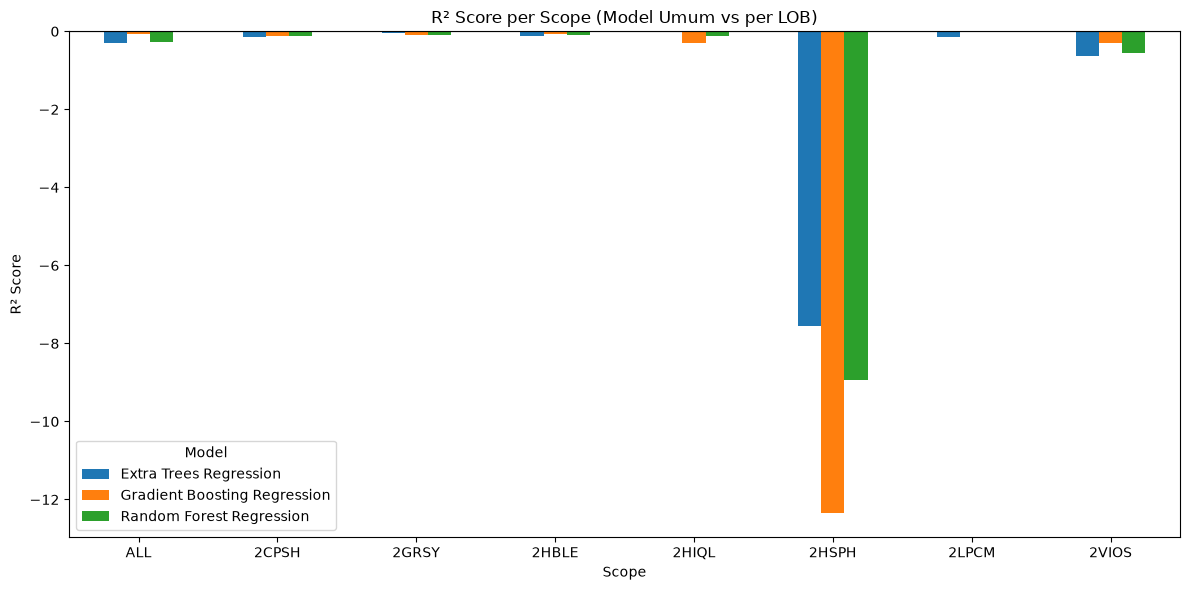

In [7]:
# perbandingan model satu keseluruhan dan misal perLOB
# apa lebih oke satu keseluruhan atau per LOB 
fig, ax = plt.subplots(figsize=(12, 6))
pivot_r2 = results_df.pivot(index="Scope", columns="Model", values="R2 Score")
# model satu keseluruhan di taro pling kiri sebagai pembanding
order = [GENERAL_SCOPE] + [s for s in pivot_r2.index if s != GENERAL_SCOPE]
pivot_r2.loc[order].plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("R² Score per Scope (Model Umum vs per LOB)")
ax.set_ylabel("R² Score")
ax.set_xlabel("Scope")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "r2_perbandingan_scope.png", dpi=150)
plt.show()

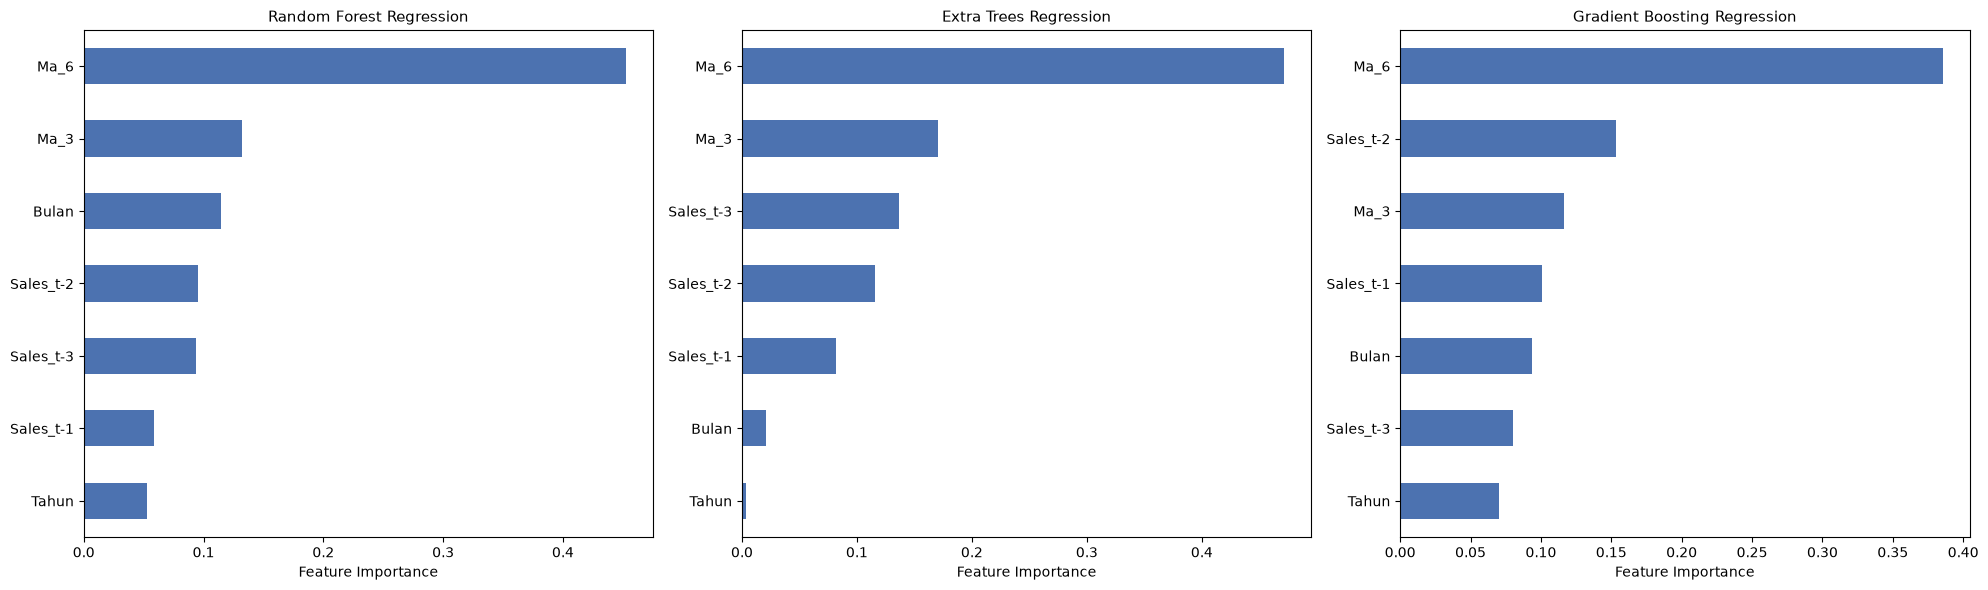

In [9]:
import joblib as _joblib

# feature importance pada tiap fitur yang digunakan
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (nama_model, (algo_key, _)) in zip(axes, MODEL_CLASSES.items()):
    model = _joblib.load(TRAINED_MODELS / model_filename(algo_key, GENERAL_SCOPE))
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(nama_model, fontsize=11)
    ax.set_xlabel("Feature Importance")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "feature_importance_model_umum.png", dpi=150)
plt.show()


In [11]:
#  forecast yang tiap prediksi dipake lagi untuk prediksi kedepannya ini buat yang t+6 bulan itu
from feature_engineering import (
    forecast_month, handle_negative_sales, fix_period_bug,
    aggregate_monthly, fill_monthly_gaps,
)

produk_contoh = df_raw["KODE_PRODUK"].value_counts().index[0]  # produk dengan histori terbanyak
hist_lengkap = fix_period_bug(handle_negative_sales(df_raw[df_raw["KODE_PRODUK"] == produk_contoh].copy(), verbose=False))

hist_lengkap = aggregate_monthly(hist_lengkap, verbose=False)
hist_lengkap = fill_monthly_gaps(hist_lengkap, verbose=False)
hist_lengkap = hist_lengkap.sort_values("PERIOD_MO").reset_index(drop=True)

print(f"Produk contoh: {produk_contoh}")
print("6 bulan histori terakhir:")
print(hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(6))

model_umum = joblib.load(TRAINED_MODELS / "random_forest_ALL.joblib")
history_values = hist_lengkap["SALES_QTY"].tolist()
last_period = hist_lengkap["PERIOD_MO"].max()

forecast = forecast_month(model_umum, history_values, last_period, horizon=6)

print("\nForecast 6 bulan ke depan:")
forecast_df = pd.DataFrame(forecast)
forecast_df

Produk contoh: PRD0001
6 bulan histori terakhir:
    PERIOD_MO  SALES_QTY
25 2025-04-01       68.0
26 2025-05-01        0.0
27 2025-06-01      160.0
28 2025-07-01      168.0
29 2025-08-01        0.0
30 2025-09-01       72.0

Forecast 6 bulan ke depan:


,tahun,bulan,predicted_quantity
0,2025,10,6200.51
1,2025,11,1643.04
2,2025,12,5158.11
3,2026,1,5239.88
4,2026,2,608.96
5,2026,3,179.71


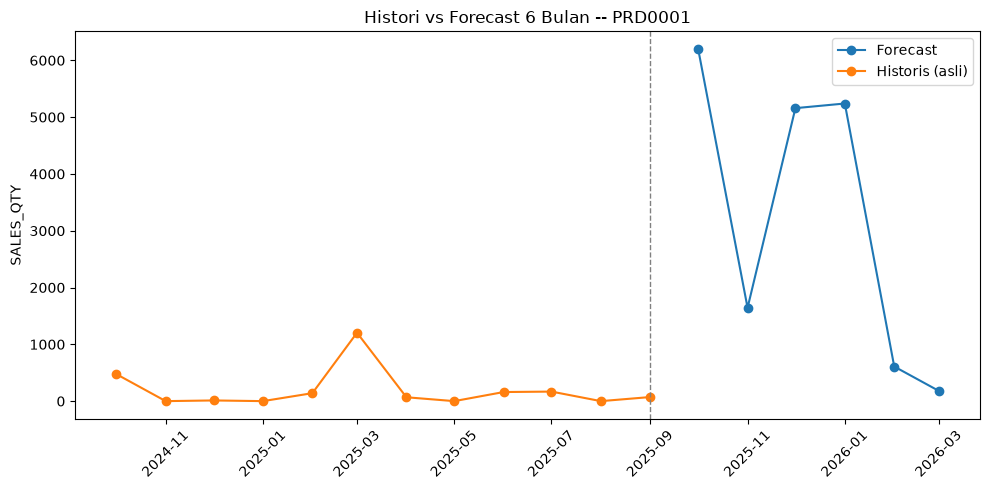

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
hist_plot = hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(12).rename(columns={"SALES_QTY": "value"})
hist_plot["tipe"] = "Historis (asli)"

forecast_plot = forecast_df.copy()
forecast_plot["PERIOD_MO"] = pd.to_datetime(
    forecast_plot["tahun"].astype(str) + "-" + forecast_plot["bulan"].astype(str) + "-01"
)
forecast_plot = forecast_plot.rename(columns={"predicted_quantity": "value"})[["PERIOD_MO", "value"]]
forecast_plot["tipe"] = "Forecast"

gabungan = pd.concat([hist_plot[["PERIOD_MO", "value", "tipe"]], forecast_plot])
for tipe, g in gabungan.groupby("tipe"):
    ax.plot(g["PERIOD_MO"], g["value"], marker="o", label=tipe)

ax.axvline(hist_lengkap["PERIOD_MO"].max(), color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Histori vs Forecast 6 Bulan -- {produk_contoh}")
ax.set_ylabel("SALES_QTY")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "contoh_forecast_6bulankedepan.png", dpi=150)
plt.show()